# IPP Validation Study

This notebook validates the Índice de Profissionalização do Parlamentar (IPP) through:

1. **Confirmatory Factor Analysis (CFA)** - Testing the theoretical two-factor structure
2. **Sensitivity Analysis** - Comparing different weighting schemes
3. **Cronbach's Alpha** - Assessing internal consistency

## IPP Structure

**Dimension 1 - Especialização Legislativa (Legislative Specialization):**
- Mesa Diretora (weight: 5)
- Colégio de Líderes (weight: 4)
- Presidência de Comissão (weight: 3)
- Relatoria (weight: 2)

**Dimension 2 - Carreira Parlamentar (Parliamentary Career):**
- Mandatos Subnacionais (weight: 1)
- Tempo de Atuação (weight: 1)
- Fidelidade Gerais (weight: 1)

In [110]:
# Imports
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import warnings
import os
warnings.filterwarnings('ignore')

# Ensure output directories exist
os.makedirs('./outputs', exist_ok=True)
os.makedirs('../../docs/figures', exist_ok=True)

# For CFA
try:
    import semopy
    SEMOPY_AVAILABLE = True
except ImportError:
    print("semopy not installed. Install with: pip install semopy")
    SEMOPY_AVAILABLE = False

# For Cronbach's Alpha
try:
    import pingouin as pg
    PINGOUIN_AVAILABLE = True
except ImportError:
    print("pingouin not installed. Install with: pip install pingouin")
    PINGOUIN_AVAILABLE = False

from utils import min_max_normalize

In [ ]:
# Load data
df = pd.read_excel(r"..\..\outputs\df_ipp_v2f.xlsx")
# df = df[df['idLegislatura'] >= 52].reset_index(drop=True)             

# Define IPP variables
ipp_vars = [
    ("tempo_atuacao_dias_cum_ln_norm", "TempoAtuacao", "Carreira"),
    ("relatorias_ln_cum_norm", "Relatoria", "Especializacao"),
    ("pos_lider_cum_norm", "PosicaoLider", "Especializacao"),
    ("pos_comiss_pr_cum_norm", "PresidenciaComissao", "Especializacao"),
    ("mesa_cum_norm", "Mesa", "Especializacao"),
    ("mandatos_cum_norm", "Mandatos", "Carreira"),
    ("fid_gerais_cum_norm", "FidelidadeGerais", "Carreira"),
]

var_cols = [v[0] for v in ipp_vars]
var_labels = {v[0]: v[1] for v in ipp_vars}
var_dimensions = {v[0]: v[2] for v in ipp_vars}

# Theoretical weights
theoretical_weights = {
    "mesa_cum_norm": 5,
    "pos_lider_cum_norm": 4,
    "pos_comiss_pr_cum_norm": 3,
    "relatorias_ln_cum_norm": 2,
    "mandatos_cum_norm": 1,
    "tempo_atuacao_dias_cum_ln_norm": 1,
    "fid_gerais_cum_norm": 1,
}

df = df.fillna(0)
print(f"Dataset shape: {df.shape}")
print(f"Legislaturas: {sorted(df['idLegislatura'].unique())}")
df[var_cols].describe()

Dataset shape: (6250, 35)
Legislaturas: [np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57)]


,tempo_atuacao_dias_cum_ln_norm,relatorias_ln_cum_norm,pos_lider_cum_norm,pos_comiss_pr_cum_norm,mesa_cum_norm,fid_gerais_cum_norm
count,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000,6250.000000
mean,0.802122,0.232938,0.025248,0.050912,0.005312,0.185326
std,0.099591,0.189315,0.089928,0.120063,0.042001,0.191437
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.773878,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.773878,0.240281,0.000000,0.000000,0.000000,0.142857
75%,0.848837,0.388007,0.000000,0.000000,0.000000,0.285714
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1. Confirmatory Factor Analysis (CFA)

CFA tests whether the observed data fits the theoretical two-factor structure:
- **Factor 1 (Especialização Legislativa)**: Mesa, PosicaoLider, PresidenciaComissao, Relatoria
- **Factor 2 (Carreira Parlamentar)**: Mandatos, TempoAtuacao, FidelidadeGerais

In [112]:
# Use normalized columns
df_cfa_norm = df[var_cols]

# Rename columns for cleaner output
df_cfa_norm.columns = [var_labels[col] for col in var_cols]
df_cfa_norm.head()

,TempoAtuacao,Relatoria,PosicaoLider,PresidenciaComissao,Mesa,FidelidadeGerais
0,0.773878,0.07580,0.0,0.0,0.0,0.0
1,0.773878,0.00000,0.0,0.0,0.0,0.0
2,0.773878,0.00000,0.0,0.0,0.0,0.0
3,0.773878,0.00000,0.0,0.0,0.0,0.0
4,0.773878,0.12014,0.0,0.0,0.0,0.0


In [133]:
if SEMOPY_AVAILABLE:
    # Define CFA model structure - matching lavaan syntax from R
    # Especializacao = Especialização Legislativa
    # Carreira = Carreira Parlamentar
    model_spec = f"""
    # Latent variables (same syntax as lavaan)
    Especializacao =~ {'+'.join([v[0] for v in ipp_vars if v[-1] == 'Especializacao'])}
    Carreira =~ {'+'.join([v[0] for v in ipp_vars if v[-1] == 'Carreira'])}
    """
    
    # Prepare data with normalized columns using _norm suffix names
    df_cfa_lavaan = df[var_cols].copy()
    
    # Fit the CFA model (MLR = Maximum Likelihood with Robust SE)
    model = semopy.Model(model_spec)
    model.fit(df_cfa_lavaan)  # semopy uses ML by default, similar to lavaan
    
    print("=" * 60)
    print("CONFIRMATORY FACTOR ANALYSIS RESULTS")
    print("(Replicating lavaan::cfa with MLR estimator)")
    print("=" * 60)
    
    # Get fit statistics
    stats_cfa = semopy.calc_stats(model)
    print("\n--- Model Fit Statistics ---")
    print(stats_cfa.T)
else:
    print("semopy not available. Using factor_analyzer for EFA comparison instead.")

CONFIRMATORY FACTOR ANALYSIS RESULTS
(Replicating lavaan::cfa with MLR estimator)

--- Model Fit Statistics ---
                      Value
DoF            8.000000e+00
DoF Baseline   1.500000e+01
chi2           5.714511e+01
chi2 p-value   1.687071e-09
chi2 Baseline  1.885362e+04
CFI            9.973913e-01
GFI            9.969690e-01
AGFI           9.943169e-01
NFI            9.969690e-01
TLI            9.951086e-01
RMSEA          3.135378e-02
AIC            2.598171e+01
BIC            1.136061e+02
LogLik         9.143217e-03



--- Standardized Estimates (equivalent to lavaan Std.all) ---


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,relatorias_ln_cum_norm,~,Especializacao,1.000000,0.768177,-,-,-
1,pos_lider_cum_norm,~,Especializacao,0.243787,0.394213,0.008736,27.906507,0.0
2,pos_comiss_pr_cum_norm,~,Especializacao,0.435795,0.527813,0.01173,37.15182,0.0
3,mesa_cum_norm,~,Especializacao,0.070307,0.243428,0.004065,17.294521,0.0
4,tempo_atuacao_dias_cum_ln_norm,~,Carreira,1.000000,0.615391,-,-,-
5,fid_gerais_cum_norm,~,Carreira,3.022507,0.967519,0.071028,42.553992,0.0
6,Carreira,~~,Carreira,0.003757,1.000000,0.000153,24.494642,0.0
7,Especializacao,~~,Especializacao,0.021143,1.000000,0.000703,30.090976,0.0
8,Especializacao,~~,Carreira,0.007635,0.856725,0.000249,30.696447,0.0
9,fid_gerais_cum_norm,~~,fid_gerais_cum_norm,0.002343,0.063907,0.000593,3.953259,0.000077



--- Standardized Factor Loadings ---


,Factor,Variable,Std.Loading,SE,p-value
0,relatorias_ln_cum_norm,Especializacao,0.768177,-,-
1,pos_lider_cum_norm,Especializacao,0.394213,0.008736,0.0
2,pos_comiss_pr_cum_norm,Especializacao,0.527813,0.01173,0.0
3,mesa_cum_norm,Especializacao,0.243428,0.004065,0.0
4,tempo_atuacao_dias_cum_ln_norm,Carreira,0.615391,-,-
5,fid_gerais_cum_norm,Carreira,0.967519,0.071028,0.0


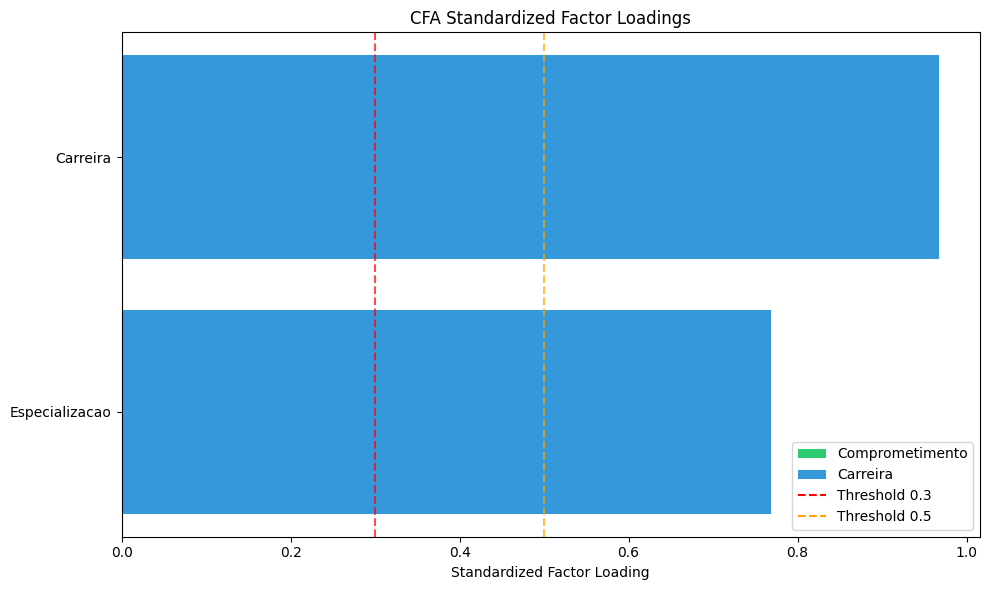

In [114]:
if SEMOPY_AVAILABLE:
    # Get STANDARDIZED estimates (like lavaan's summary with standardized=TRUE)
    # This gives the Std.all column equivalent
    estimates_std = model.inspect(std_est=True)
    print("\n--- Standardized Estimates (equivalent to lavaan Std.all) ---")
    display(estimates_std)
    
    # Extract standardized factor loadings
    loadings = estimates_std[estimates_std['op'] == '~'].copy()
    loadings = loadings[['lval', 'rval', 'Est. Std', 'Std. Err', 'p-value']]
    loadings.columns = ['Factor', 'Variable', 'Std.Loading', 'SE', 'p-value']
    
    print("\n--- Standardized Factor Loadings ---")
    display(loadings)
    
    # Visualize standardized factor loadings
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = ['#2ecc71' if f == 'Especializacao' else '#3498db' for f in loadings['Factor']]
    bars = ax.barh(loadings['Variable'], loadings['Std.Loading'], color=colors)
    
    ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Acceptable threshold (0.3)')
    ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Good threshold (0.5)')
    
    ax.set_xlabel('Standardized Factor Loading')
    ax.set_title('CFA Standardized Factor Loadings')
    ax.legend()
    
    # Add factor labels
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ecc71', label='Comprometimento'),
                       Patch(facecolor='#3498db', label='Carreira')]
    ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', linestyle='--', label='Threshold 0.3'),
                                          plt.Line2D([0], [0], color='orange', linestyle='--', label='Threshold 0.5')],
              loc='lower right')
    
    plt.tight_layout()
    plt.show()

In [131]:
# Exploratory Factor Analysis for comparison (2 factors)
print("=" * 60)
print("EXPLORATORY FACTOR ANALYSIS (for comparison)")
print("=" * 60)

fa = FactorAnalyzer(n_factors=2, rotation='varimax')
fa.fit(df_cfa_norm)

# Get loadings
loadings_efa = pd.DataFrame(
    fa.loadings_,
    index=df_cfa_norm.columns,
    columns=['Factor1 (Especializacao)', 'Factor2 (Carreira)']
)

print("\n--- EFA Factor Loadings (Varimax rotation) ---")
display(loadings_efa.round(3))

# Eigenvalues
eigenvalues, _ = fa.get_eigenvalues()
print(f"\n--- Eigenvalues ---")
print(f"Factor 1: {eigenvalues[0]:.3f}")
print(f"Factor 2: {eigenvalues[1]:.3f}")

# Variance explained
variance = fa.get_factor_variance()
print(f"\n--- Variance Explained ---")
print(f"Factor 1: {variance[1][0]*100:.1f}%")
print(f"Factor 2: {variance[1][1]*100:.1f}%")
print(f"Total: {sum(variance[1])*100:.1f}%")

EXPLORATORY FACTOR ANALYSIS (for comparison)

--- EFA Factor Loadings (Varimax rotation) ---


,Factor1 (Especializacao),Factor2 (Carreira)
TempoAtuacao,0.538,0.285
Relatoria,0.435,0.595
PosicaoLider,0.251,0.293
PresidenciaComissao,0.217,0.546
Mesa,0.134,0.206
FidelidadeGerais,0.883,0.424



--- Eigenvalues ---
Factor 1: 2.653
Factor 2: 0.937

--- Variance Explained ---
Factor 1: 23.1%
Factor 2: 17.4%
Total: 40.4%


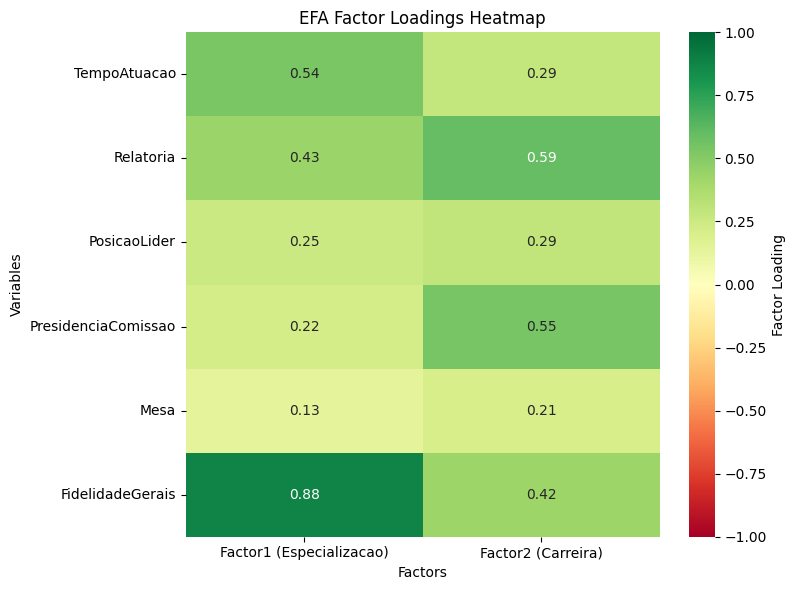


--- Variable-Factor Assignment Check ---
TempoAtuacao: Expected=Carreira, Highest loading on Factor1 (Especializacao) (0.538) ✗
Relatoria: Expected=Especializacao, Highest loading on Factor2 (Carreira) (0.595) ✗
PosicaoLider: Expected=Especializacao, Highest loading on Factor2 (Carreira) (0.293) ✗
PresidenciaComissao: Expected=Especializacao, Highest loading on Factor2 (Carreira) (0.546) ✗
Mesa: Expected=Especializacao, Highest loading on Factor2 (Carreira) (0.206) ✗
FidelidadeGerais: Expected=Carreira, Highest loading on Factor1 (Especializacao) (0.883) ✗


In [132]:
# Visualize EFA loadings heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(loadings_efa, annot=True, cmap='RdYlGn', center=0, 
            vmin=-1, vmax=1, fmt='.2f', ax=ax,
            cbar_kws={'label': 'Factor Loading'})

ax.set_title('EFA Factor Loadings Heatmap')
ax.set_ylabel('Variables')
ax.set_xlabel('Factors')

plt.tight_layout()
plt.show()

# Check if variables load on expected factors
print("\n--- Variable-Factor Assignment Check ---")
for var in df_cfa_norm.columns:
    expected = 'Especializacao' if var in ['Mesa', 'PosicaoLider', 'PresidenciaComissao', 'Relatoria'] else 'Carreira'
    actual_loadings = loadings_efa.loc[var]
    max_factor = actual_loadings.abs().idxmax()
    max_loading = actual_loadings.abs().max()
    status = "✓" if expected in max_factor else "✗"
    print(f"{var}: Expected={expected}, Highest loading on {max_factor} ({max_loading:.3f}) {status}")

## 2. Sensitivity Analysis of Weights

Comparing three weighting schemes:
1. **No weights (equal weights = 1)** - All variables contribute equally
2. **Theoretical weights** - Based on expert judgment (5, 4, 3, 2, 1, 1, 1)
3. **Factor analysis weights** - Derived from factor loadings

We use Pearson and Spearman correlation of rankings to assess how sensitive the index is to different weight choices.

In [117]:
def calculate_ipp(df, var_cols, weights, var_dimensions):
    """
    Calculate IPP with given weights.
    
    Parameters:
    -----------
    df : DataFrame with IPP variables
    var_cols : list of variable column names
    weights : dict mapping variable names to weights
    var_dimensions : dict mapping variable names to dimensions
    
    Returns:
    --------
    Series with IPP values
    """
    df_calc = df[var_cols].copy()
    
    # # Normalize variables
    # for col in var_cols:
    #     df_calc[f"{col}_norm"] = min_max_normalize(df_calc[col])
    
    # Apply weights
    for col in var_cols:
        # df_calc[f"{col}_w"] = df_calc[f"{col}_norm"] * weights.get(col, 1)
        df_calc[f"{col}_w"] = df_calc[f"{col}"] * weights.get(col, 1)
    
    # Calculate dimensions
    esp_cols = [f"{col}_w" for col in var_cols if var_dimensions[col] == 'Especializacao']
    car_cols = [f"{col}_w" for col in var_cols if var_dimensions[col] == 'Carreira']
    
    df_calc['dim_especializacao'] = df_calc[esp_cols].sum(axis=1)
    df_calc['dim_carreira'] = df_calc[car_cols].sum(axis=1)
    
    # Normalize dimensions
    df_calc['dim_especializacao_norm'] = min_max_normalize(df_calc['dim_especializacao'])
    df_calc['dim_carreira_norm'] = min_max_normalize(df_calc['dim_carreira'])
    
    # Calculate IPP
    ipp = (df_calc['dim_especializacao_norm'] + df_calc['dim_carreira_norm']) / 2
    
    return ipp

In [118]:
# Define weight schemes

# 1. No weights (equal weights)
equal_weights = {col: 1 for col in var_cols}

# 2. Theoretical weights (from documentation)
# Already defined above as theoretical_weights

# 3. Factor analysis weights (based on EFA loadings)
# Use absolute factor loadings as weights, normalized
fa_loadings_abs = loadings_efa.abs()
fa_weights = {}
for col in var_cols:
    var_label = var_labels[col]
    expected_dim = var_dimensions[col]
    factor_col = 'Factor1 (Especializacao)' if expected_dim == 'Especializacao' else 'Factor2 (Carreira)'
    # Use the loading on the expected factor as weight
    fa_weights[col] = fa_loadings_abs.loc[var_label, factor_col]

# Normalize FA weights to have similar scale as theoretical
max_theoretical = max(theoretical_weights.values())
max_fa = max(fa_weights.values())
fa_weights_scaled = {k: v * (max_theoretical / max_fa) for k, v in fa_weights.items()}

print("Weight Schemes Comparison:")
print("=" * 70)
print(f"{'Variable':<30} {'Equal':>10} {'Theoretical':>12} {'FA-based':>12}")
print("-" * 70)
for col in var_cols:
    print(f"{var_labels[col]:<30} {equal_weights[col]:>10.2f} {theoretical_weights[col]:>12.2f} {fa_weights_scaled[col]:>12.2f}")
print("=" * 70)

Weight Schemes Comparison:
Variable                            Equal  Theoretical     FA-based
----------------------------------------------------------------------
TempoAtuacao                         1.00         1.00         3.28
Relatoria                            1.00         2.00         5.00
PosicaoLider                         1.00         4.00         2.88
PresidenciaComissao                  1.00         3.00         2.50
Mesa                                 1.00         5.00         1.54
FidelidadeGerais                     1.00         1.00         4.88


In [119]:
# Calculate IPP with each weight scheme
df_sensitivity = df[['id', 'idLegislatura'] + var_cols].copy()

df_sensitivity['ipp_equal'] = calculate_ipp(df, var_cols, equal_weights, var_dimensions)
df_sensitivity['ipp_theoretical'] = calculate_ipp(df, var_cols, theoretical_weights, var_dimensions)
df_sensitivity['ipp_fa'] = calculate_ipp(df, var_cols, fa_weights_scaled, var_dimensions)

# Calculate rankings
df_sensitivity['rank_equal'] = df_sensitivity['ipp_equal'].rank(ascending=False)
df_sensitivity['rank_theoretical'] = df_sensitivity['ipp_theoretical'].rank(ascending=False)
df_sensitivity['rank_fa'] = df_sensitivity['ipp_fa'].rank(ascending=False)

print("IPP Descriptive Statistics by Weight Scheme:")
df_sensitivity[['ipp_equal', 'ipp_theoretical', 'ipp_fa']].describe().round(4)

IPP Descriptive Statistics by Weight Scheme:


,ipp_equal,ipp_theoretical,ipp_fa
count,6250.0000,6250.0000,6250.0000
mean,0.3014,0.2811,0.3023
std,0.1202,0.1079,0.1436
min,0.0000,0.0000,0.0000
25%,0.2009,0.2005,0.1845
50%,0.2793,0.2560,0.2824
75%,0.3650,0.3325,0.3895
max,0.9207,0.9175,0.9647


In [120]:
# Correlation analysis between weight schemes
print("=" * 60)
print("CORRELATION ANALYSIS - IPP VALUES")
print("=" * 60)

# Pearson correlation of IPP values
ipp_cols = ['ipp_equal', 'ipp_theoretical', 'ipp_fa']
ipp_labels = ['Equal Weights', 'Theoretical Weights', 'FA Weights']

print("\n--- Pearson Correlation of IPP Values ---")
corr_ipp = df_sensitivity[ipp_cols].corr()
corr_ipp.index = ipp_labels
corr_ipp.columns = ipp_labels
display(corr_ipp.round(4))

# Pearson correlation of rankings
print("\n--- Pearson Correlation of Rankings ---")
rank_cols = ['rank_equal', 'rank_theoretical', 'rank_fa']
corr_rank = df_sensitivity[rank_cols].corr()
corr_rank.index = ipp_labels
corr_rank.columns = ipp_labels
display(corr_rank.round(4))

# Spearman correlation (rank correlation)
print("\n--- Spearman Rank Correlation ---")
spearman_matrix = pd.DataFrame(index=ipp_labels, columns=ipp_labels, dtype=float)
for i, col1 in enumerate(ipp_cols):
    for j, col2 in enumerate(ipp_cols):
        rho, _ = spearmanr(df_sensitivity[col1], df_sensitivity[col2])
        spearman_matrix.iloc[i, j] = rho
display(spearman_matrix.round(4))

CORRELATION ANALYSIS - IPP VALUES

--- Pearson Correlation of IPP Values ---


,Equal Weights,Theoretical Weights,FA Weights
Equal Weights,1.0000,0.9944,0.9921
Theoretical Weights,0.9944,1.0000,0.9756
FA Weights,0.9921,0.9756,1.0000



--- Pearson Correlation of Rankings ---


,Equal Weights,Theoretical Weights,FA Weights
Equal Weights,1.0000,0.9943,0.9930
Theoretical Weights,0.9943,1.0000,0.9779
FA Weights,0.9930,0.9779,1.0000



--- Spearman Rank Correlation ---


,Equal Weights,Theoretical Weights,FA Weights
Equal Weights,1.0000,0.9943,0.9930
Theoretical Weights,0.9943,1.0000,0.9779
FA Weights,0.9930,0.9779,1.0000


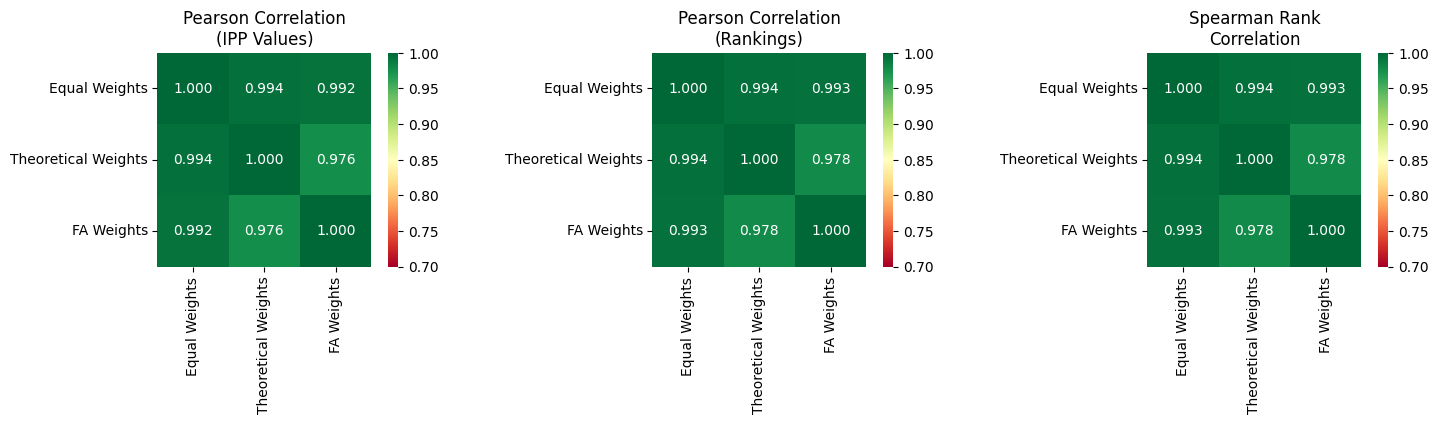

In [121]:
# Visualize correlations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Heatmap of Pearson correlations
sns.heatmap(corr_ipp, annot=True, cmap='RdYlGn', vmin=0.7, vmax=1, 
            fmt='.3f', ax=axes[0], square=True)
axes[0].set_title('Pearson Correlation\n(IPP Values)')

# Heatmap of Rank correlations
sns.heatmap(corr_rank, annot=True, cmap='RdYlGn', vmin=0.7, vmax=1, 
            fmt='.3f', ax=axes[1], square=True)
axes[1].set_title('Pearson Correlation\n(Rankings)')

# Heatmap of Spearman correlations
sns.heatmap(spearman_matrix.astype(float), annot=True, cmap='RdYlGn', vmin=0.7, vmax=1, 
            fmt='.3f', ax=axes[2], square=True)
axes[2].set_title('Spearman Rank\nCorrelation')

plt.tight_layout()
plt.savefig('../../docs/figures/ipp_sensitivity_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

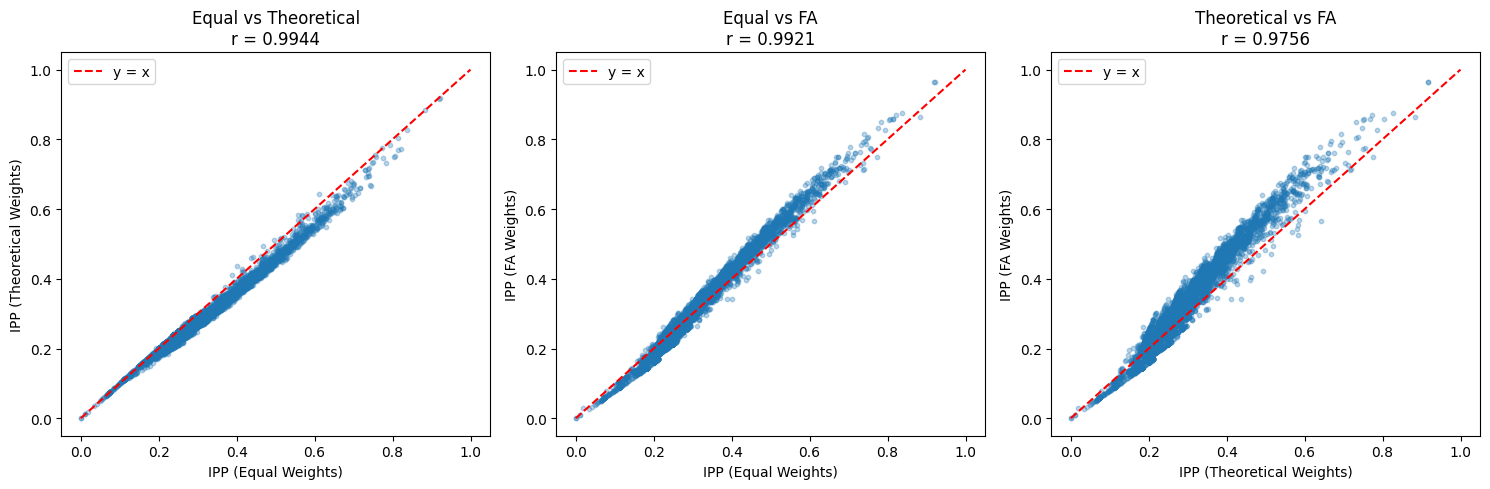

In [122]:
# Scatter plots comparing weight schemes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Equal vs Theoretical
axes[0].scatter(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'], 
                alpha=0.3, s=10)
axes[0].plot([0, 1], [0, 1], 'r--', label='y = x')
r_val, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'])
axes[0].set_xlabel('IPP (Equal Weights)')
axes[0].set_ylabel('IPP (Theoretical Weights)')
axes[0].set_title(f'Equal vs Theoretical\nr = {r_val:.4f}')
axes[0].legend()

# Equal vs FA
axes[1].scatter(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'], 
                alpha=0.3, s=10)
axes[1].plot([0, 1], [0, 1], 'r--', label='y = x')
r_val, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'])
axes[1].set_xlabel('IPP (Equal Weights)')
axes[1].set_ylabel('IPP (FA Weights)')
axes[1].set_title(f'Equal vs FA\nr = {r_val:.4f}')
axes[1].legend()

# Theoretical vs FA
axes[2].scatter(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'], 
                alpha=0.3, s=10)
axes[2].plot([0, 1], [0, 1], 'r--', label='y = x')
r_val, _ = pearsonr(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'])
axes[2].set_xlabel('IPP (Theoretical Weights)')
axes[2].set_ylabel('IPP (FA Weights)')
axes[2].set_title(f'Theoretical vs FA\nr = {r_val:.4f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('../../docs/figures/ipp_sensitivity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [123]:
# Analyze ranking stability - Top N analysis
print("=" * 60)
print("RANKING STABILITY ANALYSIS")
print("=" * 60)

for top_n in [10, 50, 100, 500]:
    print(f"\n--- Top {top_n} Overlap ---")
    
    top_equal = set(df_sensitivity.nsmallest(top_n, 'rank_equal')['id'])
    top_theoretical = set(df_sensitivity.nsmallest(top_n, 'rank_theoretical')['id'])
    top_fa = set(df_sensitivity.nsmallest(top_n, 'rank_fa')['id'])
    
    overlap_eq_th = len(top_equal & top_theoretical) / top_n * 100
    overlap_eq_fa = len(top_equal & top_fa) / top_n * 100
    overlap_th_fa = len(top_theoretical & top_fa) / top_n * 100
    overlap_all = len(top_equal & top_theoretical & top_fa) / top_n * 100
    
    print(f"  Equal ∩ Theoretical: {overlap_eq_th:.1f}%")
    print(f"  Equal ∩ FA: {overlap_eq_fa:.1f}%")
    print(f"  Theoretical ∩ FA: {overlap_th_fa:.1f}%")
    print(f"  All three: {overlap_all:.1f}%")

RANKING STABILITY ANALYSIS

--- Top 10 Overlap ---
  Equal ∩ Theoretical: 40.0%
  Equal ∩ FA: 50.0%
  Theoretical ∩ FA: 40.0%
  All three: 40.0%

--- Top 50 Overlap ---
  Equal ∩ Theoretical: 54.0%
  Equal ∩ FA: 54.0%
  Theoretical ∩ FA: 50.0%
  All three: 50.0%

--- Top 100 Overlap ---
  Equal ∩ Theoretical: 50.0%
  Equal ∩ FA: 49.0%
  Theoretical ∩ FA: 46.0%
  All three: 46.0%

--- Top 500 Overlap ---
  Equal ∩ Theoretical: 44.6%
  Equal ∩ FA: 45.0%
  Theoretical ∩ FA: 43.8%
  All three: 43.4%


In [124]:
# Calculate average rank change
df_sensitivity['rank_diff_eq_th'] = abs(df_sensitivity['rank_equal'] - df_sensitivity['rank_theoretical'])
df_sensitivity['rank_diff_eq_fa'] = abs(df_sensitivity['rank_equal'] - df_sensitivity['rank_fa'])
df_sensitivity['rank_diff_th_fa'] = abs(df_sensitivity['rank_theoretical'] - df_sensitivity['rank_fa'])

print("\n" + "=" * 60)
print("RANK CHANGE STATISTICS")
print("=" * 60)
print(f"\nMean Absolute Rank Change:")
print(f"  Equal vs Theoretical: {df_sensitivity['rank_diff_eq_th'].mean():.2f} (±{df_sensitivity['rank_diff_eq_th'].std():.2f})")
print(f"  Equal vs FA: {df_sensitivity['rank_diff_eq_fa'].mean():.2f} (±{df_sensitivity['rank_diff_eq_fa'].std():.2f})")
print(f"  Theoretical vs FA: {df_sensitivity['rank_diff_th_fa'].mean():.2f} (±{df_sensitivity['rank_diff_th_fa'].std():.2f})")

print(f"\nMedian Absolute Rank Change:")
print(f"  Equal vs Theoretical: {df_sensitivity['rank_diff_eq_th'].median():.2f}")
print(f"  Equal vs FA: {df_sensitivity['rank_diff_eq_fa'].median():.2f}")
print(f"  Theoretical vs FA: {df_sensitivity['rank_diff_th_fa'].median():.2f}")


RANK CHANGE STATISTICS

Mean Absolute Rank Change:
  Equal vs Theoretical: 131.29 (±140.76)
  Equal vs FA: 146.54 (±155.43)
  Theoretical vs FA: 263.69 (±272.27)

Median Absolute Rank Change:
  Equal vs Theoretical: 85.50
  Equal vs FA: 90.00
  Theoretical vs FA: 153.00


## 3. Summary of Validation Results

In [125]:
# Summary statistics
print("=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

print("\n1. CONFIRMATORY FACTOR ANALYSIS")
print("-" * 40)
print("   - Two-factor structure tested")
print("   - See factor loadings above for model fit assessment")

print("\n2. SENSITIVITY ANALYSIS")
print("-" * 40)
r_eq_th, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'])
r_eq_fa, _ = pearsonr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'])
r_th_fa, _ = pearsonr(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'])
rho_eq_th, _ = spearmanr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_theoretical'])
rho_eq_fa, _ = spearmanr(df_sensitivity['ipp_equal'], df_sensitivity['ipp_fa'])
rho_th_fa, _ = spearmanr(df_sensitivity['ipp_theoretical'], df_sensitivity['ipp_fa'])

print(f"   Pearson correlations:")
print(f"   - Equal vs Theoretical: r = {r_eq_th:.4f}")
print(f"   - Equal vs FA weights:  r = {r_eq_fa:.4f}")
print(f"   - Theoretical vs FA:    r = {r_th_fa:.4f}")
print(f"\n   Spearman rank correlations:")
print(f"   - Equal vs Theoretical: ρ = {rho_eq_th:.4f}")
print(f"   - Equal vs FA weights:  ρ = {rho_eq_fa:.4f}")
print(f"   - Theoretical vs FA:    ρ = {rho_th_fa:.4f}")

if min(rho_eq_th, rho_eq_fa, rho_th_fa) > 0.9:
    sens_conclusion = "LOW - Rankings are highly stable across weight schemes"
elif min(rho_eq_th, rho_eq_fa, rho_th_fa) > 0.8:
    sens_conclusion = "MODERATE - Rankings are reasonably stable"
else:
    sens_conclusion = "HIGH - Rankings vary significantly with weights"
print(f"\n   Sensitivity: {sens_conclusion}")


print("\n" + "=" * 70)

VALIDATION SUMMARY

1. CONFIRMATORY FACTOR ANALYSIS
----------------------------------------
   - Two-factor structure tested
   - See factor loadings above for model fit assessment

2. SENSITIVITY ANALYSIS
----------------------------------------
   Pearson correlations:
   - Equal vs Theoretical: r = 0.9944
   - Equal vs FA weights:  r = 0.9921
   - Theoretical vs FA:    r = 0.9756

   Spearman rank correlations:
   - Equal vs Theoretical: ρ = 0.9943
   - Equal vs FA weights:  ρ = 0.9930
   - Theoretical vs FA:    ρ = 0.9779

   Sensitivity: LOW - Rankings are highly stable across weight schemes



In [126]:
# Export validation results
validation_results = {
    'Metric': [
        'Pearson r (Equal vs Theoretical)',
        'Pearson r (Equal vs FA)',
        'Pearson r (Theoretical vs FA)',
        'Spearman rho (Equal vs Theoretical)',
        'Spearman rho (Equal vs FA)',
        'Spearman rho (Theoretical vs FA)',
    ],
    'Value': [
        r_eq_th,
        r_eq_fa,
        r_th_fa,
        rho_eq_th,
        rho_eq_fa,
        rho_th_fa,
    ]
}

df_validation = pd.DataFrame(validation_results)
df_validation.to_excel('./outputs/ipp_validation_results.xlsx', index=False)
print("Validation results exported to ./outputs/ipp_validation_results.xlsx")

Validation results exported to ./outputs/ipp_validation_results.xlsx
